## Area of Interest: Michigan Orphan Oil & Gas Wells
##### The primary issue of this dataset is a plotting of orphaned (abandoned) oil & gas well sites within the state of Michigan. As they are polluting in nature, an environmental concern is the context of both why the data was collected, and for some of the included variables. Other variables found within the data includes the year of installaton, the company of installation, if the well(s) have since been sealed or not, the names of certain cluster groups of these sites, and several other miscellaneous variables.
##### As this project works upon the work of the previous assignment, some explanatory text within the code lines remains. Additional explanatory text in the markdown lines will be provided as well.

### Importing Modules
##### The following are the necessary modules for this codebook.

In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
import requests

In [3]:
import geodatasets

In [4]:
import contextily as cx

In [5]:
import matplotlib as plt

In [ ]:
cx.providers

In [ ]:
cx.providers.Esri.WorldStreetMap

### Bringing in the Dataset
##### This dataset comes from the Michigan GIS Open Data website, the usable URL of which is used below.

In [9]:
url = "https://utility.arcgis.com/usrsvcs/servers/359eff2fb8ee49528969bce36c731d55/rest/services/EGLE/OGMDOrphanedWells/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf = gpd.read_file(url)

### Sample of the Dataset

In [10]:
# A small sample of the data, with a decent portion of the variables considered.
gdf.head()

,OrphanGroup,AssignedStaff,OrphanCategory,ProjectName,ProjectType,ProjectScore,IndividualScore,MichiganPermitNumber,PN_WELLSN,PN_WELLST,...,Comments,GlobalID,created_user,created_date,last_edited_user,last_edited_date,OBJECTID,FundingSource,Shape,geometry
0,STATE,NaN,None,None,None,NaN,NaN,7769,7769.0,PN 7769,...,None,{0EB863BB-4397-4A96-B860-0561C1FCFB47},None,None,DEQ_View,1.706553e+12,231,None,None,POINT (-85.75009 42.94924)
1,STATE,NaN,None,None,None,NaN,NaN,GT0008,NaN,PN GT0008,...,None,{49B13E93-A1EA-4459-8057-E2F6F71C2401},None,None,None,NaN,8950,None,None,POINT (-85.6601 42.6565)
2,STATE,NaN,None,None,None,NaN,NaN,NP772,NaN,PN NP772,...,None,{85CF2D49-F460-472C-8DB9-61E782D233FB},None,None,DEQ_View,1.706553e+12,76,State,None,None
3,STATE,NaN,None,None,None,NaN,NaN,32679,32679.0,PN 32679,...,None,{A83F6220-7B9C-4C71-B944-B5E8F7C74CE2},None,None,DEQ_View,1.706553e+12,77,State,None,POINT (-85.2463 43.5896)
4,STATE,NaN,None,None,None,NaN,NaN,30472,30472.0,PN 30472,...,None,{22100CA2-691A-4ACA-A30D-CF5AF3BD4686},None,None,DEQ_View,1.706553e+12,78,State,None,POINT (-85.2468 43.5845)


### Full Variable List of the Dataset

In [11]:
gdf.columns

Index(['OrphanGroup', 'AssignedStaff', 'OrphanCategory', 'ProjectName',
       'ProjectType', 'ProjectScore', 'IndividualScore',
       'MichiganPermitNumber', 'PN_WELLSN', 'PN_WELLST', 'Well_Name',
       'MichiganFacilityNumber', 'FACN2', 'FacilityName', 'LABEL', 'STATUS',
       'Data_Element', 'Element_Status', 'US_Well_ID_API', 'WellID_DataSource',
       'WellType', 'CountyName', 'TownshipName', 'TRS', 'Quarter',
       'QuarterQuarter', 'QuarterQuarterQuarter', 'DTD', 'TVD', 'FieldName',
       'FieldType', 'ProducingFormation', 'Year', 'Company', 'Longitude',
       'Latitude', 'HorizontalDatum', 'LocationAccuracy', 'RemedialAction',
       'StateHouse', 'StateSenate', 'SurfaceManagEntityType',
       'SubsurfaceManagEntityType', 'State', 'Tribe', 'PrePlugMethaneMeas',
       'PostPlugMethaneMeas', 'MethaneMeasMethod', 'HabitatRestored',
       'AmountHabitatRestored', 'RestorationEndpoint', 'DateRestoreComplete',
       'SurfWtrContamination', 'SurfWtrContamIndicator', 'SurfWt

### Variables of Interest
##### From the variable set, an interesting find is that many of the variables either don't have that much of an explanation as to what they mean, any data at all, or even both (the last being the primary case). Two possibilities may be that the dataset is incomplete, and that this dataset may originally come from an unaccessable source where these variables would be explained/given better context, such as some of the "GroundWtr" variables for example.

### Cleaning up the Variables
##### Here, I decided to select variables that I found to be both more important, and had a large sum of data entries, as much of the data for some of the variables is left blank. The chosen variables include, "OrphanGroup" which refers to a signifying code for cluster groups, "CountyName" is the county that the site is located in, "Well_Name" is the name of the orphaned oil/gas well in question, "Year" is the year of well installation, and "Element_Status" indicates if the well in question is still active or has since been plugged.

In [12]:
gdf2 = gdf[['OrphanGroup', 'CountyName', 'Well_Name', 'Year', 'Element_Status',]]
gdf2.head(50)

,OrphanGroup,CountyName,Well_Name,Year,Element_Status
0,STATE,KENT,"LIVINGSTON, JOHN & NELLIE ET AL 4",1940.0,ACTIVE
1,STATE,ALLEGAN,Eva M. Knight 1,NaN,ACTIVE
2,STATE,SAGINAW,Greenfield and Hermansau Orphan 1,NaN,PLUGGED
3,STATE,MECOSTA,"GOLUPSKI, MRS CLEO M 2-22",1979.0,PLUGGED
4,STATE,MECOSTA,"GOLUPSKI, CLEO M MRS 1-22",1975.0,PLUGGED
5,STATE,ISABELLA,"WOOD, A. ET AL 33-1",1981.0,PLUGGED
6,STATE,MIDLAND,"HENRY, WM 1",1929.0,PLUGGED
7,STATE,VAN BUREN,FUNK-DRING COMM. 3,1982.0,PLUGGED
8,STATE,VAN BUREN,FUNK 10,1981.0,PLUGGED
9,STATE,VAN BUREN,FUNK & DRING COMMUNITIZED 2,1981.0,PLUGGED


### Histogram of the "Year" Variable

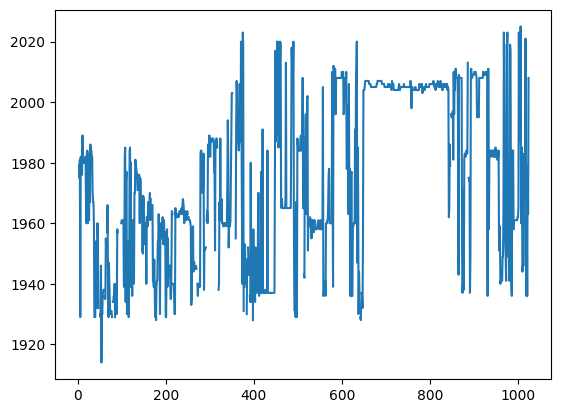

In [13]:
# The only discernible numeric data within the dataset is the year in which the Oil/Gas Wells were installed. The resulting plot is hard to read, therefore making this version unsuitable for much analysis.
gdf2['Year'].plot();

### Boxplot of the "Year" Variable
##### A question, or rather assumption with the "Year" variable, is that the majority (over 50%) of the entries for this variable are going to be pre-1960. The basis of this is the idea that oil/gas wells from the 60's can be considered old, and before substantial (or really any) environmental regulations. Given that the median of the data as presented in the boxplot is within the range of the 1970's, my question/assumption can be said to be incorrect.

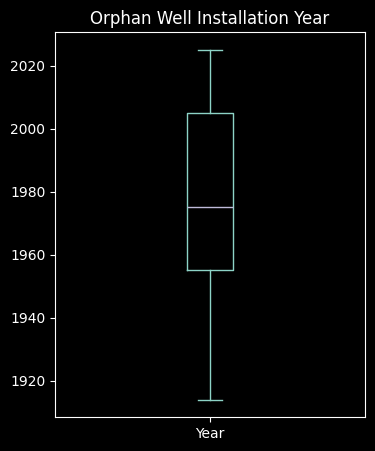

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
gdf2['Year'].plot(kind='box', figsize=(4, 5))
plt.title('Orphan Well Installation Year')
plt.show()

### Geodataframe Plot of the Dataset
##### For whatever reason, the plot background color changed from white to black when I re-ran the corresponding cell. Regardless of this change, the locations of the orphaned oil/gas wells are displayed and in a relatively Michigan-like shape. 

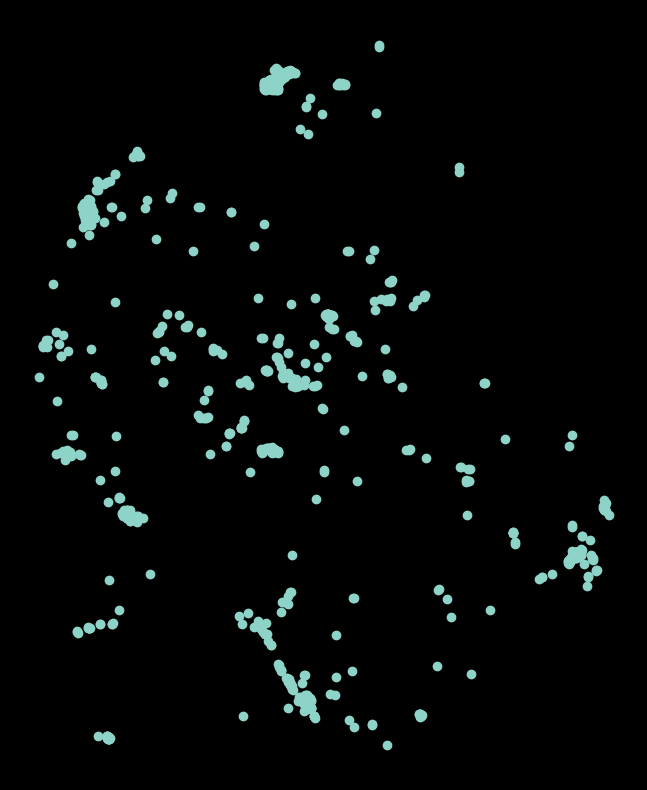

In [15]:
# This is a plot of just the points from the data without context. The last line of code here removes the random axis that can be generated for data like this in the notebook.
ax = gdf.plot(figsize=(10,10))
ax.set_axis_off();

### Map Projection Code

In [16]:
# The correction that I had to make for the projection here was not to have "gdf.plot" before ".to_crs", but "gdf", as "gdf" was defined earlier as representing the whole of the plot point data, instead of the plot that I had created above this cell. This would make sense as I am asking the code to make a projecton of the entire provided dataset insead of a generated plot.
gdf = gdf.to_crs(epsg=3857)

In [17]:
# This is to confirm that the projection/coordinate system is working.
gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Map #1
##### The basis for this basemap selection is that it shows both larger bodies of water, and a general idea of what the landcover is for the state. In tandem, it provides a more environemntal point of view regarding the potentially polluting nature of the dataset's points.

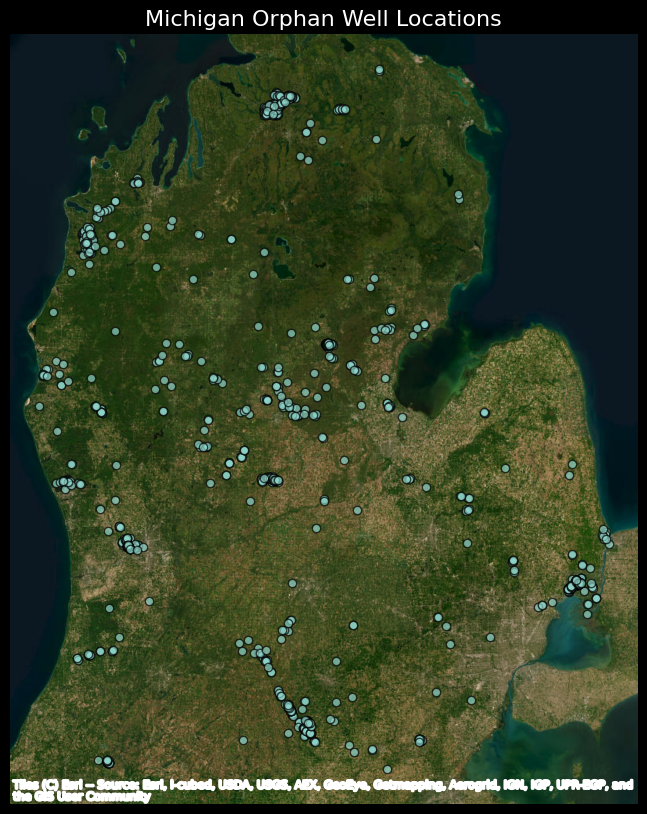

In [18]:
# I had tried to see if copying the basemap generation code from the week 5 in-class notebooks would result in anything, which expectingly resulted in errors. I then tried removing the unnecessary code from these copies, and then refered to the internet for what the remaining errors had meant. The result was finally a basemap that could be generated. The one issue at hand is that an appropriate legend could not be discertained from the overall data.  
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.7, edgecolor='black')
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)
ax.set_axis_off();
plt.title("Michigan Orphan Well Locations", fontsize = 16 )
plt.show()

### Map #2
##### The basis for this basemap selection is that it shows major roadways and city names, which in turn can provide insight onto what oil/gas wells may need to be sealed as quickly as possible due to proximity to populated areas, if they had not been sealed previously.

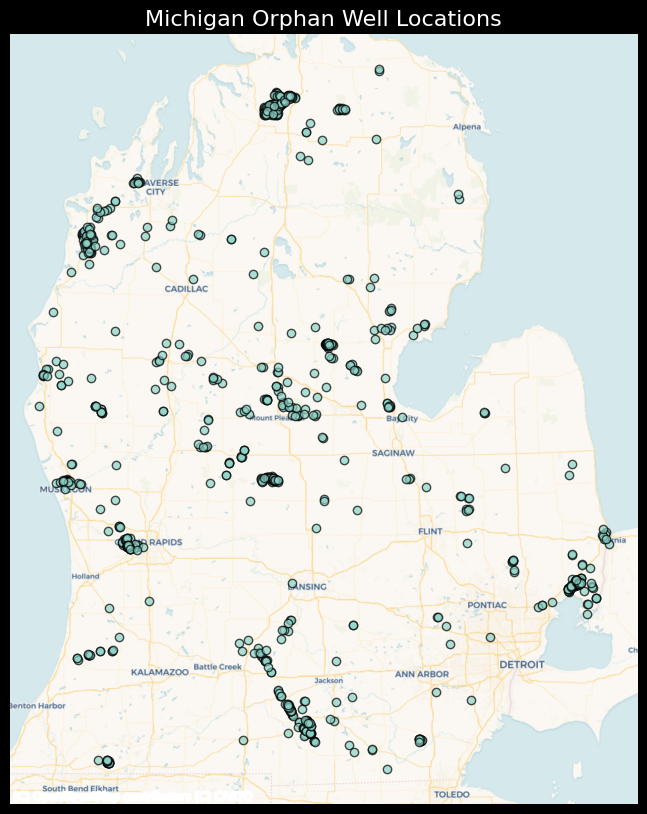

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.7, edgecolor='black')
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)
ax.set_axis_off();
plt.title("Michigan Orphan Well Locations", fontsize = 16 )
plt.show()

### Python API

##### The main idea with the following map is being able to take a created feature layer from ArcGIS Online, such as of the "Michigan Orphan Oil & Gas Wells" dataset that has been worked with, and make a map out of such a dataset.

In [20]:
# The points are not visable until you zoom in close to the landscape, try looking around Jenison for example.
from arcgis.gis import GIS
from arcgis.map import Map
gis = GIS() 
map2 = gis.map('Michigan')
map2.basemap.basemap = 'hybrid'
map2

Map()

In [21]:
# The text in green is the "Service ItemId" for the feature layer found on ArcGIS Online.
layeritem = gis.content.get("322db181057645e08e33c11a0e225cbc")
map2.content.add(layeritem)

### Summary
##### In tandem, my area of interest has been of the orphaned (abandoned) oil & gas well sites within the state of Michigan, and their problem of potential pollution. This dataset provides the plots of these sites, as seen in the plot graph, as well as in the three provided map formats. Numerous variables, of which 5 were selected due to their percived importance and volume of entries. Lastly, the "Year" variable was visualized (really the only variable that numerically could) through both a histogram (though rather unhelpful), and a boxplot (which was helpful in showing the quartiles of that variable).